In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import pandas as pd
df = pd.read_csv(r"E:\fraud-detection\fraud-detection\data\credit_card_fraud_10k.csv")
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [13]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='str')

In [15]:
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [18]:
fraud_counts = df["is_fraud"].value_counts()

print(fraud_counts)

is_fraud
0    9849
1     151
Name: count, dtype: int64


In [29]:
fraud = df[df["is_fraud"] == 1]
normal = df[df["is_fraud"] == 0] 

In [31]:
print(fraud['amount'].describe())
print(normal['amount'].describe())

count     151.000000
mean      216.182980
std       248.120467
min         0.110000
25%        41.530000
50%       118.940000
75%       341.695000
max      1185.070000
Name: amount, dtype: float64
count    9849.000000
mean      175.333015
std       173.986837
min         0.000000
25%        50.990000
50%       122.110000
75%       241.650000
max      1471.040000
Name: amount, dtype: float64


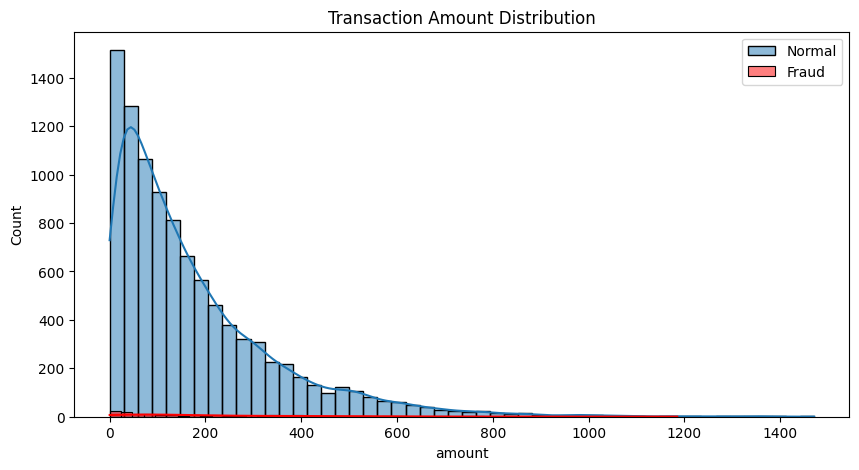

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(normal["amount"], bins=50, label="Normal", kde=True)
sns.histplot(fraud["amount"], bins=50, color="red", label="Fraud", kde=True)

plt.legend()
plt.title("Transaction Amount Distribution")

plt.show()

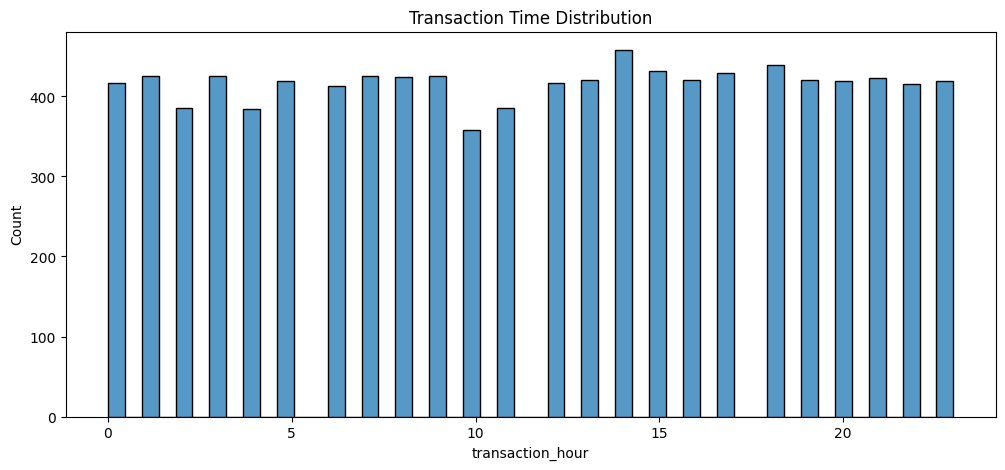

In [34]:
plt.figure(figsize=(12,5))

sns.histplot(df["transaction_hour"], bins=50)

plt.title("Transaction Time Distribution")

plt.show()

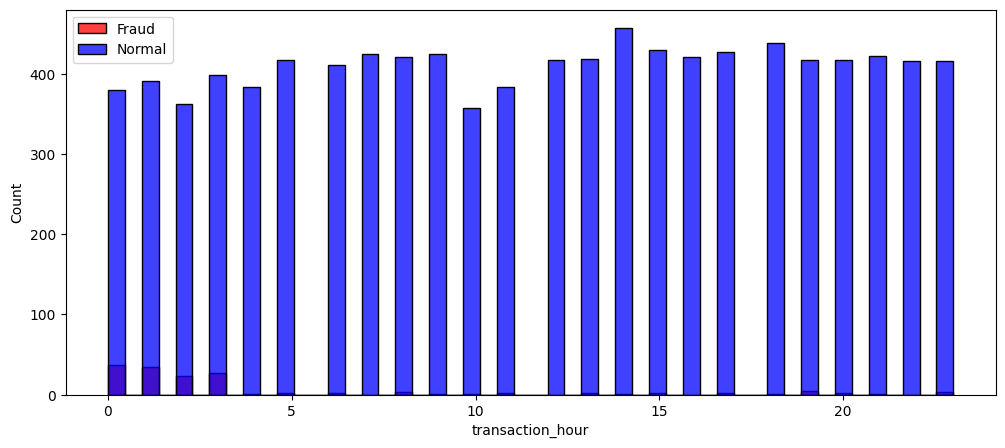

In [35]:
plt.figure(figsize=(12,5))

sns.histplot(fraud["transaction_hour"], color="red", bins=50, label="Fraud")
sns.histplot(normal["transaction_hour"], color="blue", bins=50, label="Normal")

plt.legend()

plt.show()

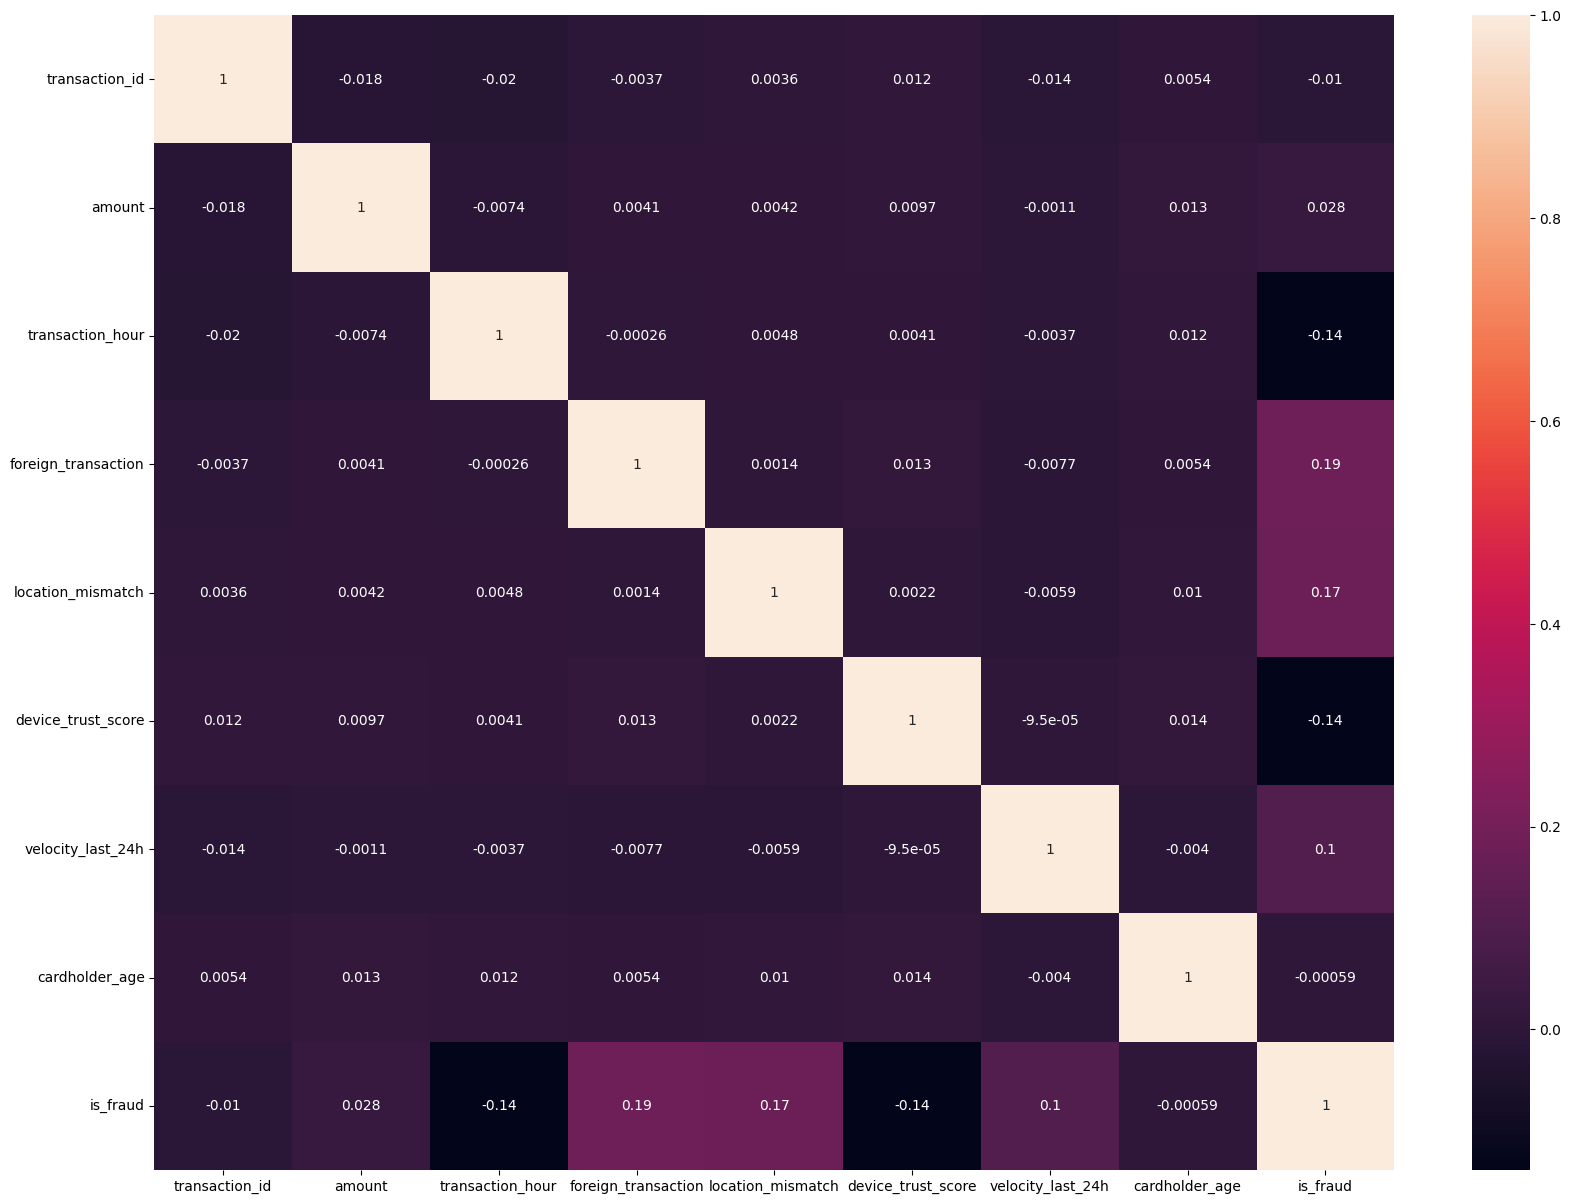

In [37]:
# This tells pandas to ignore columns with strings/objects
corr = df.corr(numeric_only=True)

# Now proceed with your plotting
plt.figure(figsize=(20, 15))
sns.heatmap(corr, annot=True)
plt.show()

<Axes: xlabel='transaction_hour', ylabel='Count'>

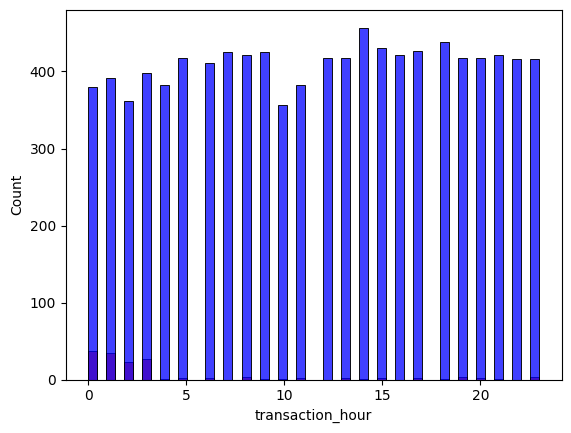

In [39]:
# If the list output showed "time" (lowercase):
sns.histplot(fraud["transaction_hour"], color="red", bins=50, label="Fraud")
sns.histplot(normal["transaction_hour"], color="blue", bins=50, label="Normal")